# Импорты

In [ ]:
pip install transformers datasets accelerate evaluate torch pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 134.9 MB/s eta 0:00:00


In [ ]:
!python -m spacy download ru_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.4/513.4 MB 2.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import numpy as np
import pandas as pd
from collections import Counter
import spacy
import pymorphy3
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split, KFold

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from tqdm.auto import tqdm
from sklearn.base import clone

from contextlib import contextmanager
import joblib
from joblib import parallel

import torch
from transformers import pipeline
from tqdm.auto import tqdm

from datasets import Dataset

# загрузка файлов

In [ ]:
FILES = [
    "/content/aggregated_results_by_ds__pool_37806285__2023_02_18.tsv",
    "/content/aggregated_results_by_ds__pool_37939772__2023_02_27.tsv",
]

def parse_category(x):
    """
    Превращает строку вида "[4]" -> 4
    (иногда может быть пробел/другой формат, поэтому используем regex).
    """
    if pd.isna(x):
        return np.nan
    m = re.search(r"-?\d+", str(x))
    return int(m.group()) if m else np.nan

def parse_confidence(x):
    """ "100.00%" -> 100.0 """
    if pd.isna(x):
        return np.nan
    return float(str(x).replace("%", "").strip())

def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    # ожидаемые колонки: INPUT:text, OUTPUT:category, CONFIDENCE:category
    df = df.rename(columns={
        "INPUT:text": "text",
        "OUTPUT:category": "category_raw",
        "CONFIDENCE:category": "confidence_raw",
    })

    df["complexity"] = df["category_raw"].apply(parse_category)
    df["confidence"] = df["confidence_raw"].apply(parse_confidence)

    # чистка
    df = df.dropna(subset=["text", "complexity"]).copy()
    df["complexity"] = df["complexity"].astype(int)

    return df[["text", "complexity", "confidence"]]


# 1) читаем оба файла
dfs = [load_one(p) for p in FILES]

# 2) собираем в единый датасет
data = pd.concat(dfs, ignore_index=True)

# выделение призаков

In [ ]:
morph = pymorphy3.MorphAnalyzer()

nlp = spacy.load("ru_core_news_lg")

# --- РУССКИЕ СЛОВАРИ (базовые) ---
ACADEMIC_WORDS_RU = {
    'анализ', 'метод', 'система', 'процесс', 'результат', 'исследование',
    'развитие', 'влияние', 'взаимодействие', 'факт', 'явление', 'функция',
    'механизм', 'структура', 'форма', 'содержание', 'противоречие', 'связь'
}

TECHNICAL_TERMS_RU = {
    'алгоритм', 'модель', 'параметр', 'функция', 'переменная', 'операция',
    'компонент', 'элемент', 'система', 'интеграция', 'оптимизация', 'протокол'
}

# Психолингвистические словари (если есть, иначе базовые)
CONCRETENESS_DICT = {
    'дом': 4.5, 'стол': 4.8, 'книга': 4.2, 'мысль': 1.5, 'идея': 1.3,
    'время': 2.1, 'число': 2.8, 'цвет': 3.5, 'звук': 4.0, 'вода': 4.6,
}

AOA_DICT = {
    'мама': 2, 'папа': 2, 'дом': 3, 'кот': 3, 'собака': 3, 'книга': 4,
    'школа': 4, 'работа': 5, 'анализ': 8, 'теория': 9, 'концепция': 10,
}

FREQUENCY_DICT_SAMPLE = {
    'и': 9.5, 'в': 9.3, 'на': 9.2, 'что': 9.0, 'он': 8.8, 'она': 8.7,
    'это': 8.6, 'быть': 8.5, 'как': 8.4, 'мир': 7.0, 'человек': 7.2,
    'анализ': 5.5, 'интеграция': 4.2, 'оптимизация': 3.8,
}

def tokenize_sentences(text):
    """Разбить текст на предложения."""
    sentences = re.split(r'[.!?]+', text)
    return [s.strip() for s in sentences if s.strip()]


def tokenize_words(text):
    """Разбить текст на слова."""
    words = re.findall(r'\b[\wа-яА-ЯёЁ-]+\b', text.lower())
    return words


def get_lemmas(words):
    """Получить леммы для слов."""
    lemmas = []
    for word in words:
        parsed = morph.parse(word)[0]
        lemmas.append(parsed.normal_form)
    return lemmas

def get_pos_tags(words):
    """Получить части речи (pymorphy)."""
    pos_tags = []
    for word in words:
        parsed = morph.parse(word)[0]
        pos_tags.append(parsed.tag.POS)
    return pos_tags

# СИНТАКСИЧЕСКИЕ ПРИЗНАКИ

def extract_syntactic_features(text):
    """Извлечь 37 синтаксических признаков."""
    features = {}
    sentences = tokenize_sentences(text)
    words = tokenize_words(text)
    pos_tags = get_pos_tags(words)

    # Длина и структура
    sentence_lengths = [len(tokenize_words(s)) for s in sentences if s]
    if sentence_lengths:
        features['sentence_length_avg'] = np.mean(sentence_lengths)
        features['sentence_length_std'] = np.std(sentence_lengths)
        features['sentence_length_max'] = np.max(sentence_lengths)
        features['sentence_length_min'] = np.min(sentence_lengths)
    else:
        features['sentence_length_avg'] = 0
        features['sentence_length_std'] = 0
        features['sentence_length_max'] = 0
        features['sentence_length_min'] = 0

    # Части речи
    pos_counter = Counter(pos_tags)
    total_pos = len(pos_tags) if pos_tags else 1

    features['verb_ratio'] = pos_counter.get('VERB', 0) / total_pos
    features['noun_ratio'] = pos_counter.get('NOUN', 0) / total_pos
    features['adjective_ratio'] = pos_counter.get('ADJF', 0) / total_pos
    features['adverb_ratio'] = pos_counter.get('ADVB', 0) / total_pos
    features['pronoun_ratio'] = pos_counter.get('PRON', 0) / total_pos
    features['preposition_ratio'] = pos_counter.get('PREP', 0) / total_pos
    features['conjunction_ratio'] = pos_counter.get('CONJ', 0) / total_pos

    # Модальные глаголы
    modal_verbs = {'может', 'можно', 'должен', 'надо', 'нужно', 'следует'}
    features['modal_verb_ratio'] = sum(1 for w in words if w in modal_verbs) / total_pos

    # Пассивный залог (примерная оценка по суффиксам)
    features['passive_voice_ratio'] = sum(1 for w in words if w.endswith('ся')) / total_pos

    # Причастия и деепричастия
    features['participle_count'] = sum(1 for tag in pos_tags if tag == 'PRTF') / len(sentences) if sentences else 0
    features['gerund_count'] = sum(1 for tag in pos_tags if tag == 'GRND') / len(sentences) if sentences else 0

    # Сложность: количество придаточных (примерно по союзам)
    subordinate_conj = {'что', 'который', 'чтобы', 'если', 'так как', 'потому что'}
    features['subordination_ratio'] = sum(1 for w in words if w in subordinate_conj) / max(1, len(sentences))

    # Вложенность (примерная: по скобкам и запятым)
    features['embedding_depth'] = text.count('(') + text.count('[')
    features['punctuation_density'] = len(re.findall(r'[,;:—–-]', text)) / max(1, len(words))

    # Предложные фразы
    features['prepositional_phrase_count'] = len([w for w in words if w in {'в', 'на', 'с', 'по', 'из', 'у', 'для', 'о', 'об', 'от', 'к'}]) / max(1, len(sentences))

    # Дополнительные признаки
    features['complex_sentences_ratio'] = sum(1 for s in sentences if len(tokenize_words(s)) > 15) / max(1, len(sentences))
    features['simple_sentences_ratio'] = sum(1 for s in sentences if len(tokenize_words(s)) <= 5) / max(1, len(sentences))
    features['ellipsis_count'] = text.count('...')
    features['parenthesis_count'] = text.count('(') + text.count(')')
    features['quotation_density'] = text.count('"') / max(1, len(words))

    # Информационная плотность
    noun_verb_count = pos_counter.get('NOUN', 0) + pos_counter.get('VERB', 0)
    features['noun_density'] = noun_verb_count / max(1, len(words))

    # Функциональные слова
    func_words = {'и', 'в', 'на', 'что', 'как', 'то', 'это', 'если', 'так'}
    features['function_word_ratio'] = sum(1 for w in words if w in func_words) / max(1, len(words))
    features['content_word_ratio'] = 1 - features['function_word_ratio']

    return features

# ЛЕКСИЧЕСКИЕ ПРИЗНАКИ

def extract_lexical_features(text):
    """Извлечь 48 лексических признаков."""
    features = {}
    words = tokenize_words(text)
    lemmas = get_lemmas(words)

    if not words:
        return {f: 0 for f in ['TTR', 'lemma_TTR', 'word_length_avg', 'word_length_std',
                               'rare_words_percentage', 'academic_words_ratio', 'technical_terms_ratio',
                               'unique_words_ratio', 'long_words_ratio', 'high_frequency_words_ratio']}

    # TTR и разнообразие
    unique_words = len(set(words))
    unique_lemmas = len(set(lemmas))
    features['TTR'] = unique_words / len(words)
    features['lemma_TTR'] = unique_lemmas / len(lemmas) if lemmas else 0
    features['MSTTR'] = features['TTR'] * (1 - features['TTR'] / len(words))  # Modified TTR

    # Уникальные слова
    word_freq = Counter(words)
    features['unique_words_ratio'] = sum(1 for count in word_freq.values() if count == 1) / len(words)
    features['high_frequency_words_ratio'] = sum(1 for w in words if word_freq[w] > 2) / len(words)

    # Длина слов
    word_lengths = [len(w) for w in words]
    features['word_length_avg'] = np.mean(word_lengths)
    features['word_length_std'] = np.std(word_lengths)
    features['long_words_ratio'] = sum(1 for w in words if len(w) > 6) / len(words)

    # Сложность лексики
    features['academic_words_ratio'] = sum(1 for w in lemmas if w in ACADEMIC_WORDS_RU) / len(words)
    features['technical_terms_ratio'] = sum(1 for w in lemmas if w in TECHNICAL_TERMS_RU) / len(words)

    # Частотность
    avg_freq = np.mean([FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in words])
    features['word_frequency_mean'] = avg_freq
    features['word_frequency_std'] = np.std([FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in words])

    # Редкие слова (частотность < 5.0)
    features['rare_words_percentage'] = sum(1 for w in words if FREQUENCY_DICT_SAMPLE.get(w, 5.0) < 5.0) / len(words)

    # Полисемия (примерно)
    features['polysemy_avg'] = np.mean([len(morph.parse(w)) for w in words])

    # Повторяемость
    max_freq = max(word_freq.values()) if word_freq else 1
    features['repeat_ratio'] = max_freq / len(words)

    # Однокоренные слова
    root_patterns = Counter()
    for w in words:
        root = morph.parse(w)[0].normal_form
        root_patterns[root[:3]] += 1  # Первые 3 буквы как приблизительный корень
    features['cognate_density'] = max(root_patterns.values()) / len(words) if root_patterns else 0

    # Синонимия (примерно: повторение лемм)
    lemma_freq = Counter(lemmas)
    features['synonym_density'] = sum(1 for count in lemma_freq.values() if count > 1) / len(lemmas) if lemmas else 0

    # Лексическая связность (перекрытие соседних предложений)
    sentences = tokenize_sentences(text)
    if len(sentences) > 1:
        overlaps = []
        for i in range(len(sentences) - 1):
            words1 = set(tokenize_words(sentences[i]))
            words2 = set(tokenize_words(sentences[i + 1]))
            if words1 or words2:
                overlaps.append(len(words1 & words2) / max(len(words1), len(words2)))
        features['lexical_cohesion'] = np.mean(overlaps) if overlaps else 0
    else:
        features['lexical_cohesion'] = 0

    return features

# ПСИХОЛИНГВИСТИЧЕСКИЕ ПРИЗНАКИ

def extract_psycholinguistic_features(text):
    """Извлечь 25 психолингвистических признаков."""
    features = {}
    words = tokenize_words(text)
    lemmas = get_lemmas(words)

    if not words:
        return {f: 0 for f in ['AoA_mean', 'AoA_std', 'concreteness_mean', 'concreteness_std',
                               'predictability_mean', 'surprisal_mean']}

    # Age of Acquisition (AoA)
    aoa_values = [AOA_DICT.get(w, 6.0) for w in lemmas]
    features['AoA_mean'] = np.mean(aoa_values)
    features['AoA_std'] = np.std(aoa_values)
    features['early_acquired_ratio'] = sum(1 for v in aoa_values if v < 5) / len(aoa_values)
    features['late_acquired_ratio'] = sum(1 for v in aoa_values if v > 8) / len(aoa_values)

    # Concreteness (конкретность)
    concreteness_values = [CONCRETENESS_DICT.get(w, 2.5) for w in lemmas]
    features['concreteness_mean'] = np.mean(concreteness_values)
    features['concreteness_std'] = np.std(concreteness_values)
    features['abstract_word_ratio'] = sum(1 for v in concreteness_values if v < 2.5) / len(concreteness_values)
    features['concrete_word_ratio'] = sum(1 for v in concreteness_values if v > 3.5) / len(concreteness_values)

    # Предсказуемость (surprisal) — примерная оценка по частотности
    freq_values = [FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in lemmas]
    features['word_frequency_mean_lex'] = np.mean(freq_values)
    features['predictability_mean'] = np.mean([1 / (1 + np.exp(-f)) for f in freq_values])  # Sigmoid

    # Surprisal как -log(p) частотности
    surprisal_values = [-np.log(max(0.001, f / 10.0)) for f in freq_values]  # Нормировка
    features['surprisal_mean'] = np.mean(surprisal_values)
    features['surprisal_std'] = np.std(surprisal_values)
    features['surprisal_max'] = max(surprisal_values) if surprisal_values else 0

    # Знакомость (примерно = обратное AoA)
    features['familiarity_mean'] = 10 - features['AoA_mean']
    features['familiarity_std'] = features['AoA_std']

    # Эмоциональная валентность (примерно по наличию слов)
    positive_words = {'хороший', 'красивый', 'отличный', 'замечательный', 'прекрасный'}
    negative_words = {'плохой', 'ужасный', 'страшный', 'ненавидеть', 'жалко'}
    features['emotional_valence'] = (sum(1 for w in lemmas if w in positive_words) -
                                      sum(1 for w in lemmas if w in negative_words)) / max(1, len(lemmas))

    # Информационность (content words vs function words)
    features['information_density'] = sum(1 for w in lemmas if len(w) > 4) / len(lemmas)

    return features

# СЕМАНТИЧЕСКИЕ ПРИЗНАКИ

def extract_semantic_features(text):
    """Извлечь 20 семантических признаков."""
    features = {}
    words = tokenize_words(text)
    sentences = tokenize_sentences(text)

    if not words:
        return {f: 0 for f in ['entity_density', 'semantic_coherence', 'topic_coherence']}

    # Плотность сущностей (примерно: по POS)
    pos_tags = get_pos_tags(words)
    noun_count = sum(1 for tag in pos_tags if tag == 'NOUN')
    features['entity_density'] = noun_count / len(words)

    # Перекрытие сущностей между предложениями
    if len(sentences) > 1:
        overlaps = []
        for i in range(len(sentences) - 1):
            nouns1 = set(w for w, tag in zip(tokenize_words(sentences[i]),
                                              get_pos_tags(tokenize_words(sentences[i])))
                        if tag == 'NOUN')
            nouns2 = set(w for w, tag in zip(tokenize_words(sentences[i + 1]),
                                              get_pos_tags(tokenize_words(sentences[i + 1])))
                        if tag == 'NOUN')
            if nouns1 or nouns2:
                overlaps.append(len(nouns1 & nouns2) / max(len(nouns1), len(nouns2)))
        features['entity_overlap'] = np.mean(overlaps) if overlaps else 0
    else:
        features['entity_overlap'] = 0

    # Кореферентность (примерно: местоимения)
    pronouns = {'он', 'она', 'оно', 'они', 'это', 'тот', 'этот'}
    features['pronoun_antecedent_distance'] = np.mean([min(i, len(words) - i)
                                                        for i, w in enumerate(words) if w in pronouns]) if any(w in pronouns for w in words) else 0

    # Причинно-следственные отношения
    causal_markers = {'потому', 'поэтому', 'следовательно', 'так как', 'вследствие'}
    features['causal_relation_density'] = sum(1 for w in words if w in causal_markers) / max(1, len(sentences))

    # Временные ссылки
    temporal_markers = {'когда', 'после', 'перед', 'затем', 'потом', 'раньше', 'позже'}
    features['temporal_reference_count'] = sum(1 for w in words if w in temporal_markers) / max(1, len(sentences))

    # Пространственные ссылки
    spatial_markers = {'где', 'здесь', 'там', 'рядом', 'близко', 'далеко', 'перед', 'позади'}
    features['spatial_reference_count'] = sum(1 for w in words if w in spatial_markers) / max(1, len(sentences))

    # Отрицания
    negation_words = {'не', 'нет', 'никто', 'ничто', 'никакой'}
    features['negation_ratio'] = sum(1 for w in words if w in negation_words) / len(words)
    features['negation_scope'] = np.mean([len(w) for w in words if w in negation_words]) if any(w in negation_words for w in words) else 0

    # Семантическая когерентность (примерно: по лексическому перекрытию)
    if len(sentences) > 1:
        coherences = []
        for i in range(len(sentences) - 1):
            words1 = set(tokenize_words(sentences[i]))
            words2 = set(tokenize_words(sentences[i + 1]))
            if words1 or words2:
                coherences.append(len(words1 & words2) / max(len(words1), len(words2)))
        features['semantic_coherence'] = np.mean(coherences) if coherences else 0
    else:
        features['semantic_coherence'] = 0

    # Тематическая связность (примерно: разнообразие слов)
    unique_words = len(set(words))
    features['topic_coherence'] = 1 - (unique_words / len(words)) if words else 0

    # Реферативная связность (лексическое чейнинг)
    word_freq = Counter(words)
    features['referential_cohesion'] = sum(1 for count in word_freq.values() if count > 1) / len(word_freq)

    # Информационная плотность (уже считали, но повторим)
    content_words = sum(1 for w in words if len(w) > 4)
    features['information_density'] = content_words / len(words)

    return features

# МОРФОЛОГИЧЕСКИЕ ПРИЗНАКИ

def extract_morphological_features(text):
    """Извлечь 10 морфологических признаков."""
    features = {}
    words = tokenize_words(text)

    if not words:
        return {f: 0 for f in ['case_variety', 'tense_variety', 'mood_variety', 'aspect_variety']}

    # Разнообразие морфологических форм
    morph_forms = Counter()
    cases = Counter()
    tenses = Counter()
    moods = Counter()
    aspects = Counter()

    for word in words:
        parsed = morph.parse(word)[0]
        tag = parsed.tag

        morph_forms[str(tag)] += 1

        if tag.case:
            cases[tag.case] += 1
        if tag.tense:
            tenses[tag.tense] += 1
        if tag.mood:
            moods[tag.mood] += 1
        if tag.aspect:
            aspects[tag.aspect] += 1

    # Разнообразие
    features['morphological_diversity'] = len(morph_forms) / len(words)
    features['case_variety'] = len(cases) / max(1, sum(cases.values()))
    features['tense_variety'] = len(tenses) / max(1, sum(tenses.values()))
    features['mood_variety'] = len(moods) / max(1, sum(moods.values()))
    features['aspect_variety'] = len(aspects) / max(1, sum(aspects.values()))

    # Префиксы и суффиксы
    prefix_count = sum(1 for w in words if w.startswith(('не', 'при', 'пре', 'про', 'раз', 'без')))
    suffix_count = sum(1 for w in words if w.endswith(('ся', 'ал', 'ение', 'ость', 'ость')))
    features['prefix_count'] = prefix_count / len(words)
    features['suffix_count'] = suffix_count / len(words)
    features['inflection_complexity'] = len(morph_forms) / len(words)

    return features

# КОМБИНИРОВАННЫЕ ПРИЗНАКИ

def extract_combined_features(syntactic, lexical, psycholing):
    """Извлечь 5 комбинированных признаков."""
    features = {}

    features['syntactic_lex_interaction'] = (syntactic.get('sentence_length_avg', 1) *
                                             lexical.get('TTR', 0.5))
    features['surprisal_word_length_interaction'] = (psycholing.get('surprisal_mean', 0) *
                                                      lexical.get('word_length_avg', 1))
    features['frequency_concreteness_interaction'] = (lexical.get('word_frequency_mean', 5) *
                                                       psycholing.get('concreteness_mean', 2.5))
    features['TTR_sentence_length_interaction'] = (lexical.get('TTR', 0.5) *
                                                    syntactic.get('sentence_length_avg', 1))
    features['complexity_combined'] = (syntactic.get('sentence_length_avg', 0) *
                                       lexical.get('word_length_avg', 0) *
                                       psycholing.get('surprisal_mean', 0))

    return features

SUBORD_LEMMAS = {
    "что", "чтобы", "если", "когда", "поскольку", "потому", "хотя",
    "который", "которая", "которые"
}

CLAUSAL_DEPS = {"ROOT", "ccomp", "xcomp", "advcl", "acl", "relcl", "parataxis"}
NP_HEAD_DEPS = {"nsubj", "obj", "iobj", "obl", "nmod", "appos", "conj"}

def features_from_paper(sent: str) -> dict:
    doc = nlp(sent)

    # sen_len (chars) — как в статье
    sen_len = len(sent)

    # Avg_token_length — средняя длина токена (букв) без пунктуации
    toks = [t for t in doc if not t.is_punct and not t.is_space]
    avg_token_length = float(np.mean([len(t.text) for t in toks])) if toks else 0.0

    # Prop_* — доли частей речи
    n = len(toks) if toks else 1
    prop_nouns = sum(1 for t in toks if t.pos_ in {"NOUN", "PROPN"}) / n
    prop_verbs = sum(1 for t in toks if t.pos_ in {"VERB", "AUX"}) / n
    prop_adjectives = sum(1 for t in toks if t.pos_ in {"ADJ"}) / n
    prop_pronouns = sum(1 for t in toks if t.pos_ in {"PRON", "DET"}) / n

    # Average_path_length / Maximum_path_length:
    # dependency distance = |i - head_i|
    dists = []
    for t in toks:
        if t.head == t:          # root
            continue
        dists.append(abs(t.i - t.head.i))
    average_path_length = float(np.mean(dists)) if dists else 0.0
    maximum_path_length = int(np.max(dists)) if dists else 0

    # Num_subordinating_conjunctions:
    # 1) pos_ == SCONJ (подчинительные союзы)
    # 2) + некоторые частые леммы (что/чтобы/который...) чтобы покрыть относит. местоимения
    num_subordinating_conjunctions = sum(
        1 for t in toks
        if (t.pos_ == "SCONJ") or (t.lemma_.lower() in SUBORD_LEMMAS)
    )

    # Num_clauses:
    # практичный proxy: количество "клауза-голов" среди VERB/AUX по dependency labels + ROOT
    num_clauses = sum(
        1 for t in toks
        if (t.pos_ in {"VERB", "AUX"}) and (t.dep_ in CLAUSAL_DEPS)
    )
    num_clauses = max(1, num_clauses) if any(t.pos_ in {"VERB", "AUX"} for t in toks) else 0

    # Num_phrases:
    # так как noun_chunks для ru может быть недоступен, считаем число NP-голов (proxy)
    num_phrases = sum(
        1 for t in toks
        if (t.pos_ in {"NOUN", "PROPN", "PRON"}) and (t.dep_ in NP_HEAD_DEPS)
    )

    # Average_freq:
    # сюда позже подключите реальный частотный ресурс (wordfreq / частотный словарь)
    average_freq = np.nan

    return {
        "Average_path_length": average_path_length,
        "Maximum_path_length": maximum_path_length,
        "Num_clauses": int(num_clauses),
        "Num_phrases": int(num_phrases),
        "Num_subordinating_conjunctions": int(num_subordinating_conjunctions),
        "Prop_nouns": float(prop_nouns),
        "Prop_verbs": float(prop_verbs),
        "Prop_adjectives": float(prop_adjectives),
        "Prop_pronouns": float(prop_pronouns),
        "Average_freq": average_freq,
        "Avg_token_length": avg_token_length,
        "sen_len": int(sen_len),
    }

# ГЛАВНАЯ ФУНКЦИЯ ДЛЯ ВСЕХ ПРИЗНАКОВ

def extract_all_features(text):
    """Извлечь все признаки."""

    syntactic = extract_syntactic_features(text)
    lexical = extract_lexical_features(text)
    psycholing = extract_psycholinguistic_features(text)
    semantic = extract_semantic_features(text)
    morphological = extract_morphological_features(text)
    combined = extract_combined_features(syntactic, lexical, psycholing)
    paper = features_from_paper(text)

    # Объединить все
    all_features = {
        **{f'synt_{k}': v for k, v in syntactic.items()},
        **{f'lex_{k}': v for k, v in lexical.items()},
        **{f'psych_{k}': v for k, v in psycholing.items()},
        **{f'sem_{k}': v for k, v in semantic.items()},
        **{f'morph_{k}': v for k, v in morphological.items()},
        **{f'comb_{k}': v for k, v in combined.items()},
        **{f'paper_{k}': v for k, v in paper.items()},
    }

    return all_features

In [ ]:
if __name__ == "__main__":
    # Загружаем ваши предложения
    df = data

    # Извлекаем признаки для каждого предложения
    print("Извлечение признаков... (это займет некоторое время)")

    features_list = []
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"Обработано {idx} предложений...")

        text = row['text']
        features = extract_all_features(text)
        features['sentence'] = text
        features['complexity'] = row['complexity']
        features['confidence'] = row['confidence']
        features_list.append(features)

    # Создаем DataFrame с признаками
    features_df = pd.DataFrame(features_list)

    # Сохраняем
    features_df.to_csv('ru_sentences_with_features.csv', index=False)
    print(f"✅ Готово! Всего признаков: {len(features_df.columns) - 3}")
    print(f"Сохранено в: ru_sentences_with_features.csv")
    print(f"\nПервые признаки:")
    print(features_df.iloc[0, :15])

Извлечение признаков... (это займет некоторое время)
Обработано 0 предложений...
Обработано 100 предложений...
Обработано 200 предложений...
Обработано 300 предложений...
Обработано 400 предложений...
Обработано 500 предложений...
Обработано 600 предложений...
Обработано 700 предложений...
Обработано 800 предложений...
Обработано 900 предложений...
Обработано 1000 предложений...
Обработано 1100 предложений...
✅ Готово! Всего признаков: 99
Сохранено в: ru_sentences_with_features.csv

Первые признаки:
synt_sentence_length_avg    20.0
synt_sentence_length_std     0.0
synt_sentence_length_max      20
synt_sentence_length_min      20
synt_verb_ratio             0.05
synt_noun_ratio             0.45
synt_adjective_ratio        0.05
synt_adverb_ratio            0.0
synt_pronoun_ratio           0.0
synt_preposition_ratio      0.05
synt_conjunction_ratio       0.2
synt_modal_verb_ratio        0.0
synt_passive_voice_ratio     0.0
synt_participle_count        0.0
synt_gerund_count            1.0


In [ ]:
device = 0 if torch.cuda.is_available() else -1
print(f"Используем устройство: {'GPU' if device==0 else 'CPU'}")

Используем устройство: GPU


In [ ]:
X = features_df.drop(columns=["complexity", "sentence"], errors="ignore")

all_nan_cols = X.columns[X.isna().all()].tolist()
print("All-NaN columns:", all_nan_cols)

X = X.drop(columns=all_nan_cols)
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
y = features_df["complexity"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

All-NaN columns: ['paper_Average_freq']


# Жанры

In [ ]:
# Инициализируем пайплайн с явным указанием device
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=device
)

# Кандидаты (Академическая классификация)
candidate_labels = [
    "Публицистический стиль",        # Новости, блоги, статьи СМИ, эссе
    "Художественный стиль",          # Романы, поэзия, драматургия, фольклор
    "Научный стиль",                 # Статьи, диссертации, монографии, учебники
    "Официально-деловой стиль",      # Законы, указы, протоколы, договоры
    "Технический стиль",             # Инструкции, спецификации, документация к ПО
    "Разговорный стиль",             # Чаты, диалоги, расшифровки интервью, форумы
    "Справочно-энциклопедический"    # Словари, вики-статьи, каталоги
]


print("Начинаем классификацию...")
texts = features_df['sentence'].tolist()
batch_size = 32
results = []

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    res = classifier(batch, candidate_labels, multi_label=False)
    results.extend(res)

# Сохраняем и строим график
predicted_genres = [r['labels'][0] for r in results]
features_df['predicted_genre'] = predicted_genres

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

Device set to use cuda:0


Начинаем классификацию...


  0%|          | 0/38 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


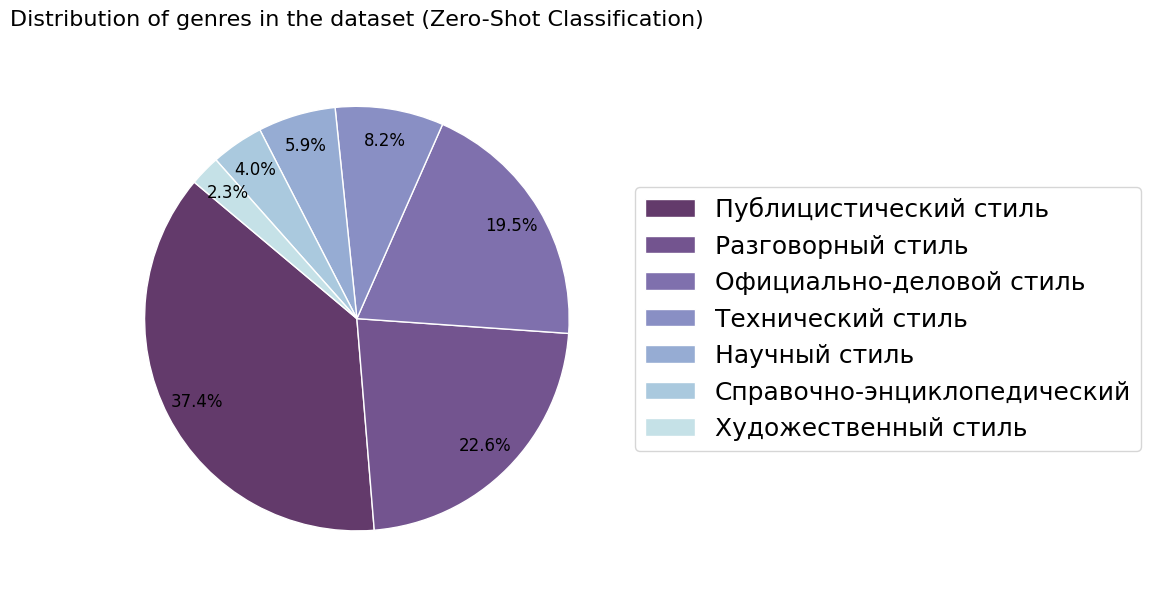

In [ ]:
plt.figure(figsize=(10, 8))

data = features_df['predicted_genre'].value_counts()
n_categories = len(data)
data = features_df['predicted_genre'].value_counts()

colors = sns.cubehelix_palette(n_colors=n_categories, start=0.8, rot=-0.5, dark=0.3, light=0.85, reverse=True)

data.plot.pie(
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85,
    textprops={'fontsize': 12},
    labels=None,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

plt.title('Distribution of genres in the dataset (Zero-Shot Classification)', fontsize=16, pad=20)
plt.ylabel('')

plt.legend(
    labels=data.index,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=18
)

plt.tight_layout()
plt.show()

# rubert

Токенизация данных...


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2715660912.py:75: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Начинаем обучение (Fine-tuning)...


Epoch,Training Loss,Validation Loss,Mae,Rmse,Mape,R2
1,1.548000,1.319049,0.947589,1.148499,0.256545,0.617967
2,1.067900,1.329334,0.914580,1.152967,0.253393,0.614988
3,0.744500,1.350861,0.927831,1.162265,0.256432,0.608753
4,0.551100,1.238048,0.885739,1.112676,0.260094,0.641427
5,0.376100,1.204714,0.876079,1.097595,0.250748,0.651081
6,0.273500,1.258528,0.882724,1.121841,0.244553,0.635495
7,0.209500,1.261672,0.881204,1.123207,0.245288,0.634607
8,0.149200,1.223473,0.865329,1.105694,0.241581,0.645913
9,0.108600,1.199827,0.860561,1.095021,0.239098,0.652716
10,0.085800,1.220892,0.866314,1.104603,0.239525,0.646612


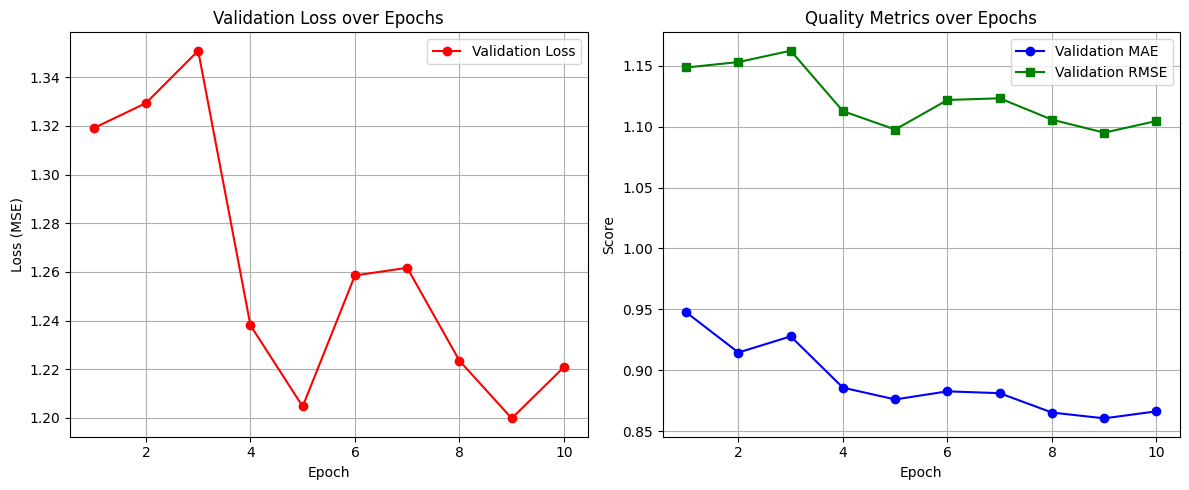


=== Итоговые метрики модели RuBERT (Regression) ===


MAE: 0.8606
MSE: 1.1991
RMSE: 1.0950
MAPE: 0.2391
R2: 0.6527


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Подготовка данных
df_bert = features_df[['sentence', 'complexity']].copy()
df_bert.columns = ['text', 'label']
df_bert['label'] = df_bert['label'].astype(float)

train_df, test_df = train_test_split(df_bert, test_size=0.2, random_state=42)

# Конвертация в формат HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Токенизация
MODEL_NAME = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Токенизация данных...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Настройка Модели
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1
)

# Метрики для Trainer
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions[:, 0]
    predictions = np.clip(predictions, 1.0, 7.0)

    mae = mean_absolute_error(labels, predictions)
    mse = mean_squared_error(labels, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(labels, predictions)
    r2 = r2_score(labels, predictions)

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./rubert_complexity_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="mae",
    greater_is_better=False,
    logging_dir='./logs',
    logging_steps=10,
    report_to="none"
)

# апуск обучения
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("Начинаем обучение (Fine-tuning)...")
train_result = trainer.train()

# Анализ результатов
history = trainer.state.log_history
train_logs = [x for x in history if 'loss' in x and 'epoch' in x]
eval_logs = [x for x in history if 'eval_mae' in x]

epochs = [x['epoch'] for x in eval_logs]
val_mae = [x['eval_mae'] for x in eval_logs]
val_rmse = [x['eval_rmse'] for x in eval_logs]
val_loss = [x['eval_loss'] for x in eval_logs]

plt.figure(figsize=(12, 5))

# График 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, val_loss, label='Validation Loss', marker='o', color='red')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()

# График 2: MAE & RMSE
plt.subplot(1, 2, 2)
plt.plot(epochs, val_mae, label='Validation MAE', marker='o', color='blue')
plt.plot(epochs, val_rmse, label='Validation RMSE', marker='s', color='green')
plt.title('Quality Metrics over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== Итоговые метрики модели RuBERT (Regression) ===")
predictions_output = trainer.predict(tokenized_test)
preds_regression = predictions_output.predictions[:, 0]
true_labels = predictions_output.label_ids

preds_regression = np.clip(preds_regression, 1.0, 7.0)

rubert_metrics = {
    "MAE": mean_absolute_error(true_labels, preds_regression),
    "MSE": mean_squared_error(true_labels, preds_regression),
    "RMSE": np.sqrt(mean_squared_error(true_labels, preds_regression)),
    "MAPE": mean_absolute_percentage_error(true_labels, preds_regression),
    "R2": r2_score(true_labels, preds_regression)
}

for k, v in rubert_metrics.items():
    print(f"{k}: {v:.4f}")

# Гибрид RandomForest + RuBert

In [ ]:
features_df = features_df.drop(columns=['sentence'])

X = features_df.drop(columns=["complexity", "sentence"], errors="ignore")

all_nan_cols = X.columns[X.isna().all()].tolist()
print("All-NaN columns:", all_nan_cols)

X = X.drop(columns=all_nan_cols)
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
y = features_df["complexity"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

All-NaN columns: ['paper_Average_freq']


In [ ]:
def clip_1_7(pred):
    return np.clip(pred, 1.0, 7.0)

In [ ]:
# RandomForest
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )),
])

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Сбор предсказаний базовых моделей...")

# RuBERT
# Получаем предсказания для обучающей выборки (чтобы обучить мета-модель)
train_preds_bert = trainer.predict(tokenized_train).predictions[:, 0]
# Получаем предсказания для тестовой выборки (для финальной проверки)
test_preds_bert = trainer.predict(tokenized_test).predictions[:, 0]

# RandomForest
rf_pipe.fit(X_train, y_train)
train_preds_rf = rf_pipe.predict(X_train)
test_preds_rf = rf_pipe.predict(X_test)

# Формирование мета-датасета
X_meta_train = pd.DataFrame({
    'rubert': train_preds_bert,
    'rf': train_preds_rf
})

X_meta_test = pd.DataFrame({
    'rubert': test_preds_bert,
    'rf': test_preds_rf
})

# Обучение мета-модели (Stacking)
# Линейная регрессия найдет, кому доверять больше
meta_model = LinearRegression()
meta_model.fit(X_meta_train, y_train)

# Вывод весов (кто важнее?)
w_bert = meta_model.coef_[0]
w_rf = meta_model.coef_[1]
bias = meta_model.intercept_
print(f"\nВеса ансамбля: RuBERT = {w_bert:.3f}, RandomForest = {w_rf:.3f}")
print(f"Смещение (bias): {bias:.3f}")

Сбор предсказаний базовых моделей...



Веса ансамбля: RuBERT = 0.722, RandomForest = 0.299
Смещение (bias): 0.001


In [ ]:
# прогноз и оценка
hybrid_pred = meta_model.predict(X_meta_test)
hybrid_pred = np.clip(hybrid_pred, 1.0, 7.0)

# Метрики
hybrid_metrics = {
    "MAE": mean_absolute_error(y_test, hybrid_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, hybrid_pred)),
    "R2": r2_score(y_test, hybrid_pred),
    "MSE": mean_squared_error(y_test, hybrid_pred),
    "MAPE": mean_absolute_percentage_error(y_test, hybrid_pred),
    "R2": r2_score(true_labels, preds_regression)
}

print("\n=== Hybrid Model Metrics ===")
for k, v in hybrid_metrics.items():
    print(f"{k}: {v:.4f}")

# Сравнение
print("\nСравнение MAE:")
print(f"RuBERT only: {mean_absolute_error(y_test, test_preds_bert):.4f}")
print(f"RF only:     {mean_absolute_error(y_test, test_preds_rf):.4f}")

rubert_metrics = {
    "MAE": mean_absolute_error(true_labels, preds_regression),
    "MSE": mean_squared_error(true_labels, preds_regression),
    "RMSE": np.sqrt(mean_squared_error(true_labels, preds_regression)),
    "MAPE": mean_absolute_percentage_error(true_labels, preds_regression),
    "R2": r2_score(true_labels, preds_regression)
}
print(f"Hybrid:      {hybrid_metrics['MAE']:.4f}")


=== Hybrid Model Metrics ===
MAE: 0.8262
RMSE: 1.0519
R2: 0.6527
MSE: 1.1066
MAPE: 0.2387

Сравнение MAE:
RuBERT only: 0.8619
RF only:     0.8643
Hybrid:      0.8262


# проверка на одном предложении

In [ ]:
def predict_single_sentence(sentence, rf_pipe, bert_trainer, meta_model):
    """
    Прогноз для одного предложения с учетом всех фиксов (удаление лишних колонок и т.д.)
    """
    print(f"Анализ: '{sentence}'")

    # Признаки для RF
    feats = extract_all_features(sentence)
    X_rf = pd.DataFrame([feats])

    if "paper_Average_freq" in X_rf.columns:
        X_rf = X_rf.drop(columns="paper_Average_freq")
    if "confidence" not in X_rf.columns:
        X_rf["confidence"] = 100

    if 'X_train' in globals():
        for col in X_train.columns:
            if col not in X_rf.columns:
                X_rf[col] = 0
        X_rf = X_rf[X_train.columns]

    # Прогноз RF
    pred_rf = rf_pipe.predict(X_rf)[0]

    # RuBERT
    tmp_ds = Dataset.from_dict({'text': [sentence]})
    tmp_tok = tmp_ds.map(tokenize_function, batched=True)
    pred_bert = bert_trainer.predict(tmp_tok).predictions[0, 0]

    # гибрид
    X_meta = pd.DataFrame({'rubert': [pred_bert], 'rf': [pred_rf]})
    pred_hybrid = meta_model.predict(X_meta)[0]
    final_score = np.clip(pred_hybrid, 1.0, 7.0)

    print(f"RF: {pred_rf:.2f} | BERT: {pred_bert:.2f} | HYBRID: {final_score:.2f}")
    return final_score

# Тест
text = "В этом случае определяется время завершения игры в игровой день , и по достижении этого времени игрок , чья очередь ходить , должен отложить партию , которая затем доигрывается в определенный турнирными правилами день."
predict_single_sentence(text, rf_pipe, trainer, meta_model)

Анализ: 'В этом случае определяется время завершения игры в игровой день , и по достижении этого времени игрок , чья очередь ходить , должен отложить партию , которая затем доигрывается в определенный турнирными правилами день .'


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

RF: 6.67 | BERT: 6.92 | HYBRID: 6.99


np.float64(6.992741840565376)

In [ ]:
text = "При этом МИ должны быть зарегистрированы в установленном порядке, установлены (размещены, смонтированы, введены в эксплуатацию) в соответствии с требованиями нормативной и эксплуатационной документации, укомплектованы соответствующей эксплуатационной документацией и в случае необходимости - запасными частями и принадлежностями."
predict_single_sentence(text, rf_pipe, trainer, meta_model)

Анализ: 'При этом МИ должны быть зарегистрированы в установленном порядке, установлены (размещены, смонтированы, введены в эксплуатацию) в соответствии с требованиями нормативной и эксплуатационной документации, укомплектованы соответствующей эксплуатационной документацией и в случае необходимости - запасными частями и принадлежностями.'


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

RF: 6.49 | BERT: 5.45 | HYBRID: 5.88


np.float64(5.880665876388513)

# прогон наших текстов

In [ ]:
# функция для разбиения на предложения
def split_into_sentences(text):
    sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s', text)
    return [s.strip() for s in sentences if len(s.strip()) > 1]

# функция обработки файла
def process_file_with_hybrid_model(filepath, rf_pipeline, bert_trainer, meta_model, delimiter=';'):

    # Читаем файл
    try:
        df = pd.read_csv(filepath, sep=delimiter)
    except Exception as e:
        print(f"Ошибка чтения: {e}")
        return None

    all_results = []

    # Ищем колонку с текстом
    text_col = next((c for c in df.columns if c.strip().lower() in ['текст', 'text']), None)
    if not text_col:
        print(f"Колонки в файле: {df.columns.tolist()}")
        raise ValueError("Не найдена колонка 'Текст'")

    print(f"Обработка {len(df)} текстов...")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        original_text = row[text_col]
        cat_col = next((c for c in df.columns if c.strip().lower() in ['категория', 'category']), None)
        category = row[cat_col] if cat_col else 'Unknown'

        sentences = split_into_sentences(str(original_text))
        if not sentences:
            continue

        # RF Features
        feats_list = [extract_all_features(s) for s in sentences]
        X_rf = pd.DataFrame(feats_list)

        if "paper_Average_freq" in X_rf.columns:
            X_rf = X_rf.drop(columns="paper_Average_freq")

        if "confidence" not in X_rf.columns:
            X_rf["confidence"] = 100

        if 'X_train' in globals():
            for col in X_train.columns:
                if col not in X_rf.columns:
                    X_rf[col] = 0
            X_rf = X_rf[X_train.columns]

        preds_rf = rf_pipeline.predict(X_rf)

        # RuBERT
        tmp_ds = Dataset.from_dict({'text': sentences})
        tmp_tok = tmp_ds.map(tokenize_function, batched=True)
        preds_bert = bert_trainer.predict(tmp_tok).predictions[:, 0]

        # Hybrid
        X_meta = pd.DataFrame({'rubert': preds_bert, 'rf': preds_rf})
        preds_hybrid = meta_model.predict(X_meta)
        preds_hybrid = np.clip(preds_hybrid, 1.0, 7.0)

        # Агрегация
        avg_score = np.mean(preds_hybrid)

        all_results.append({
            'original_id': idx,
            'category': category,
            'text_snippet': str(original_text)[:50] + "...",
            'avg_complexity': round(avg_score, 2),
            'all_scores': [round(x, 2) for x in preds_hybrid]
        })

    return pd.DataFrame(all_results)



FILE_PATH = "стимулы_для_оценки.csv"
final_stats = process_file_with_hybrid_model(FILE_PATH, rf_pipe, trainer, meta_model, delimiter=';')

if final_stats is not None:
    print("\n=== Результаты ===")
    print(final_stats.head())

    # Сохраняем
    final_stats.to_csv("final_complexity_analysis.csv", index=False)
    print("\nФайл сохранен: final_complexity_analysis.csv")


Обработка 239 текстов...


  0%|          | 0/239 [00:00<?, ?it/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

  0%|          | 1/239 [00:00<01:28,  2.70it/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/5 [00:00<?, ? examples/s]

100%|█████████▉| 238/239 [01:20<00:00,  2.78it/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

100%|██████████| 239/239 [01:21<00:00,  2.94it/s]


=== Результаты ===
   original_id  category                                       text_snippet  \
0            0  Оригинал  ТО подлежат МИ, в том числе находящиеся в эксп...   
1            1  Оригинал  Испытательные давления для стальных трубопрово...   
2            2  Оригинал  В случае исполнения работ по ТО собственной сл...   
3            3  Оригинал  После ремонта МИ, способного оказать влияние н...   
4            4  Оригинал  Оценку качества функционирования системы ТО ме...   

   avg_complexity    all_scores  
0            5.74  [5.61, 5.88]  
1            5.20         [5.2]  
2            6.97        [6.97]  
3            6.89        [6.89]  
4            5.94  [5.65, 6.23]  

Файл сохранен: final_complexity_analysis.csv


In [ ]:
final_stats.head()

,original_id,category,text_snippet,avg_complexity,all_scores
0,0,Оригинал,"ТО подлежат МИ, в том числе находящиеся в эксп...",5.74,"[5.61, 5.88]"
1,1,Оригинал,Испытательные давления для стальных трубопрово...,5.20,[5.2]
2,2,Оригинал,В случае исполнения работ по ТО собственной сл...,6.97,[6.97]
3,3,Оригинал,"После ремонта МИ, способного оказать влияние н...",6.89,[6.89]
4,4,Оригинал,Оценку качества функционирования системы ТО ме...,5.94,"[5.65, 6.23]"


In [ ]:
final_stats.groupby('category')['avg_complexity'].mean()

,avg_complexity
category,
Оригинал,6.297059
версия1,4.241569
версия2,5.199412
версия3,5.349412
версия4,5.565429


# Сохранение модели

In [ ]:
import os
import joblib
import json
import shutil
from google.colab import files

# 1. Создаем локальную папку для сборки
MODEL_DIR = "/content/MyComplexityModel_Hybrid"
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"📂 Создана папка: {MODEL_DIR}")

# --- А. Сохраняем sklearn модели ---
joblib.dump(rf_pipe, os.path.join(MODEL_DIR, "rf_pipeline.joblib"))
joblib.dump(meta_model, os.path.join(MODEL_DIR, "meta_model.joblib"))
print("✅ RandomForest и Meta-model сохранены.")

# --- Б. Сохраняем RuBERT ---
# Trainer сохранит конфиг, веса и токенайзер
trainer.save_model(os.path.join(MODEL_DIR, "rubert_finetuned"))
tokenizer.save_pretrained(os.path.join(MODEL_DIR, "rubert_finetuned"))
print("✅ RuBERT сохранен.")

# --- В. Сохраняем список признаков ---
if 'X_train' in locals():
    feature_cols = list(X_train.columns)
    with open(os.path.join(MODEL_DIR, "rf_features.json"), "w") as f:
        json.dump(feature_cols, f)
    print("✅ Список признаков сохранен.")
else:
    print("⚠️ X_train не найден (признаки не сохранены).")

# 2. Архивируем всё в один ZIP-файл
print("\n📦 Архивируем файлы...")
shutil.make_archive("/content/complexity_model", 'zip', MODEL_DIR)
print("✅ Архив complexity_model.zip создан!")

# 3. Скачиваем
files.download("/content/complexity_model.zip")

📂 Создана папка: /content/MyComplexityModel_Hybrid
✅ RandomForest и Meta-model сохранены.
✅ RuBERT сохранен.
✅ Список признаков сохранен.

📦 Архивируем файлы...
✅ Архив complexity_model.zip создан!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>